In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [3]:
df = pd.read_excel("Final_dataset.xlsx")

print("Dataset Shape:", df.shape)
print("Columns:", df.columns)

df.head()

Dataset Shape: (8769, 11)
Columns: Index(['Bulk density (g/cm³)', 'Porosity (%)',
       'Carbonization temperature (˚C)', 'Heating rate (˚C/min)',
       'Holding time (hr)', 'Precursor', 'Precursor_Category', 'Strain (%)',
       'Stress (MPa)', 'Compressive strength (Mpa)',
       'Log_Compressive_Strength'],
      dtype='object')


,Bulk density (g/cm³),Porosity (%),Carbonization temperature (˚C),Heating rate (˚C/min),Holding time (hr),Precursor,Precursor_Category,Strain (%),Stress (MPa),Compressive strength (Mpa),Log_Compressive_Strength
0,0.067,96.6,900,5,2,tannin-based,Biomass-based,1.890359,0.012658,0.52,-0.653926
1,0.067,96.6,900,5,2,tannin-based,Biomass-based,3.780718,0.016878,0.52,-0.653926
2,0.067,96.6,900,5,2,tannin-based,Biomass-based,4.914934,0.025316,0.52,-0.653926
3,0.067,96.6,900,5,2,tannin-based,Biomass-based,6.238185,0.037975,0.52,-0.653926
4,0.067,96.6,900,5,2,tannin-based,Biomass-based,7.372401,0.046414,0.52,-0.653926


In [4]:
# ======================
# STRESS DATA PREPARATION
# ======================

y_stress = df["Stress (MPa)"]

X_stress = df.drop(columns=[
    "Stress (MPa)",
    "Compressive strength (Mpa)",
    "Log_Compressive_Strength",
    "Precursor"
])

X_stress = pd.get_dummies(X_stress, columns=["Precursor_Category"], drop_first=True)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_stress, y_stress,
    test_size=0.2,
    random_state=42
)

In [5]:
y = df["Log_Compressive_Strength"]

X = df.drop(columns=[
    "Compressive strength (Mpa)",
    "Log_Compressive_Strength",
    "Precursor"
])

X = pd.get_dummies(X, columns=["Precursor_Category"], drop_first=True)

print("Final Feature Shape:", X.shape)
print(X.columns)

Final Feature Shape: (8769, 9)
Index(['Bulk density (g/cm³)', 'Porosity (%)',
       'Carbonization temperature (˚C)', 'Heating rate (˚C/min)',
       'Holding time (hr)', 'Strain (%)', 'Stress (MPa)',
       'Precursor_Category_Other', 'Precursor_Category_Polymer-based'],
      dtype='object')


In [27]:
# ================================
# STRESS MODEL FULL METRICS
# ================================

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

y_pred_s = xgb_stress.predict(X_test_s)

r2_s = r2_score(y_test_s, y_pred_s)
rmse_s = np.sqrt(mean_squared_error(y_test_s, y_pred_s))
mae_s = mean_absolute_error(y_test_s, y_pred_s)

print("\n=== STRESS MODEL METRICS ===")
print(f"R2  : {r2_s:.4f}")
print(f"RMSE: {rmse_s:.4f}")
print(f"MAE : {mae_s:.4f}")


=== STRESS MODEL METRICS ===
R2  : 0.8841
RMSE: 0.4453
MAE : 0.1773


In [7]:
# Stress-Strain Model

y_stress = df["Stress (MPa)"]

X_stress = df.drop(columns=[
    "Stress (MPa)",
    "Compressive strength (Mpa)",
    "Log_Compressive_Strength",
    "Precursor"
])

X_stress = pd.get_dummies(X_stress, columns=["Precursor_Category"], drop_first=True)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_stress, y_stress,
    test_size=0.2,
    random_state=42
)

print("Stress Model Ready")

Stress Model Ready


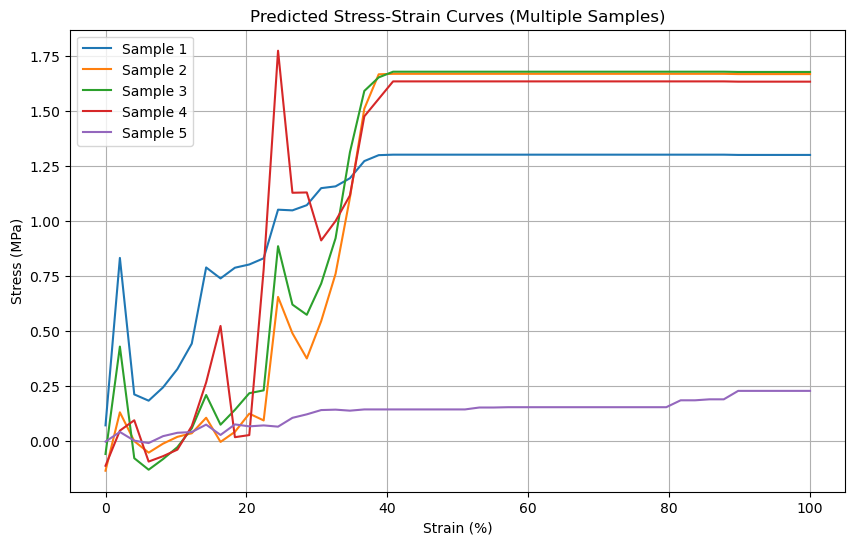

In [28]:
# ================================
# MULTIPLE STRESS-STRAIN CURVES
# ================================

plt.figure(figsize=(10,6))

for i in range(5):
    sample = X_test_s.iloc[i:i+1].copy()
    
    strain_range = np.linspace(0, 100, 50)
    stress_preds = []
    
    for strain in strain_range:
        temp = sample.copy()
        temp["Strain (%)"] = strain
        
        pred = xgb_stress.predict(temp)[0]
        stress_preds.append(pred)
    
    plt.plot(strain_range, stress_preds, label=f"Sample {i+1}")

plt.xlabel("Strain (%)")
plt.ylabel("Stress (MPa)")
plt.title("Predicted Stress-Strain Curves (Multiple Samples)")
plt.legend()
plt.grid()

plt.show()

In [10]:
rf_stress = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf_stress.fit(X_train_s, y_train_s)

pred_stress = rf_stress.predict(X_test_s)

print("Stress Model R2:", r2_score(y_test_s, pred_stress))

Stress Model R2: 0.9054629382444793


In [11]:
# ======================
# XGBOOST STRESS MODEL
# ======================

xgb_stress = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_stress.fit(X_train_s, y_train_s)

pred_xgb = xgb_stress.predict(X_test_s)

print("XGBoost Stress R2:", r2_score(y_test_s, pred_xgb))

XGBoost Stress R2: 0.8840583619813609


In [ ]:
# Generate Stress-Strain Curve

sample = X_test_s.iloc[0:1].copy()

strain_range = np.linspace(0, 100, 50)

stress_predictions = []

for strain in strain_range:
    sample_copy = sample.copy()
    sample_copy["Strain (%)"] = strain
    
    stress_pred = xgb_stress.predict(sample_copy)[0]
    stress_predictions.append(stress_pred)

# Plot Curve
plt.figure(figsize=(8,5))

plt.plot(strain_range, stress_predictions, linewidth=3)

plt.xlabel("Strain (%)")
plt.ylabel("Stress (MPa)")
plt.title("Predicted Stress-Strain Curve")

plt.grid()

plt.show()

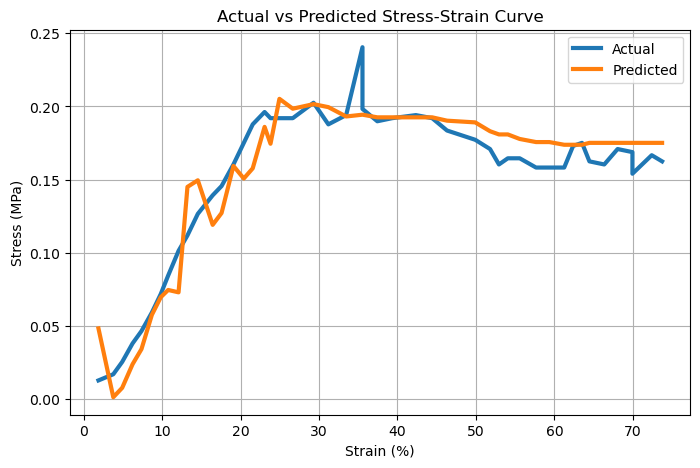

In [12]:
# Compare Actual vs Predicted Curve

# Pick one sample group
sample_index = 0

sample_data = df.iloc[sample_index:sample_index+50]

actual_strain = sample_data["Strain (%)"]
actual_stress = sample_data["Stress (MPa)"]

# Predict
X_sample = sample_data.drop(columns=[
    "Stress (MPa)",
    "Compressive strength (Mpa)",
    "Log_Compressive_Strength",
    "Precursor"
])

X_sample = pd.get_dummies(X_sample, columns=["Precursor_Category"], drop_first=True)

# align columns
X_sample = X_sample.reindex(columns=X_stress.columns, fill_value=0)

predicted_stress = xgb_stress.predict(X_sample)

# Plot
plt.figure(figsize=(8,5))

plt.plot(actual_strain, actual_stress, label="Actual", linewidth=3)
plt.plot(actual_strain, predicted_stress, label="Predicted", linewidth=3)

plt.xlabel("Strain (%)")
plt.ylabel("Stress (MPa)")
plt.title("Actual vs Predicted Stress-Strain Curve")

plt.legend()
plt.grid()

plt.show()

In [13]:
import joblib

joblib.dump(rf_stress, "rf_stress_model.pkl")
joblib.dump(xgb_stress, "xgb_stress_model.pkl")

['xgb_stress_model.pkl']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (7015, 9)
Test: (1754, 9)


In [16]:
# Initialize
lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=300, random_state=42)
xgb = XGBRegressor(
    n_estimators=400,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

# Predict
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)
xgb_pred = xgb.predict(X_test)

In [17]:
def evaluate(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    print(f"\n{name}")
    print("R2:", round(r2,4))
    print("RMSE:", round(rmse,4))
    print("MAE:", round(mae,4))
    return r2

r2_lr = evaluate("Linear Regression", y_test, lr_pred)
r2_rf = evaluate("Random Forest", y_test, rf_pred)
r2_xgb = evaluate("XGBoost", y_test, xgb_pred)


Linear Regression
R2: 0.9377
RMSE: 0.4527
MAE: 0.341

Random Forest
R2: 1.0
RMSE: 0.0062
MAE: 0.0004

XGBoost
R2: 0.9981
RMSE: 0.0795
MAE: 0.0605


In [31]:
# ================================
# FINAL COMPRESSIVE STRENGTH METRICS (REAL VALUES)
# ================================

from sklearn.metrics import r2_score

r2_real = r2_score(actual_mpa, predicted_mpa)

print("\n=== FINAL COMPRESSIVE STRENGTH METRICS ===")
print(f"R2 (MPa scale): {r2_real:.4f}")
print(f"RMSE (MPa): {rmse_mpa:.4f}")
print(f"MAE (MPa): {mae_mpa:.4f}")


=== FINAL COMPRESSIVE STRENGTH METRICS ===
R2 (MPa scale): 0.9864
RMSE (MPa): 4.7184
MAE (MPa): 2.1287


In [30]:
actual_mpa = 10 ** y_test
predicted_mpa = 10 ** ensemble_pred

rmse_mpa = np.sqrt(mean_squared_error(actual_mpa, predicted_mpa))
mae_mpa = mean_absolute_error(actual_mpa, predicted_mpa)

print("Real RMSE (MPa):", round(rmse_mpa,3))
print("Real MAE (MPa):", round(mae_mpa,3))

Real RMSE (MPa): 4.718
Real MAE (MPa): 2.129


In [20]:
total = r2_rf + r2_xgb
w_rf = r2_rf / total
w_xgb = r2_xgb / total

ensemble_pred = (w_rf * rf_pred) + (w_xgb * xgb_pred)

r2_ens = r2_score(y_test, ensemble_pred)
rmse_ens = np.sqrt(mean_squared_error(y_test, ensemble_pred))
mae_ens = mean_absolute_error(y_test, ensemble_pred)

print("\nEnsemble")
print("R2:", round(r2_ens,4))
print("RMSE:", round(rmse_ens,4))
print("MAE:", round(mae_ens,4))


Ensemble
R2: 0.9995
RMSE: 0.0401
MAE: 0.0304


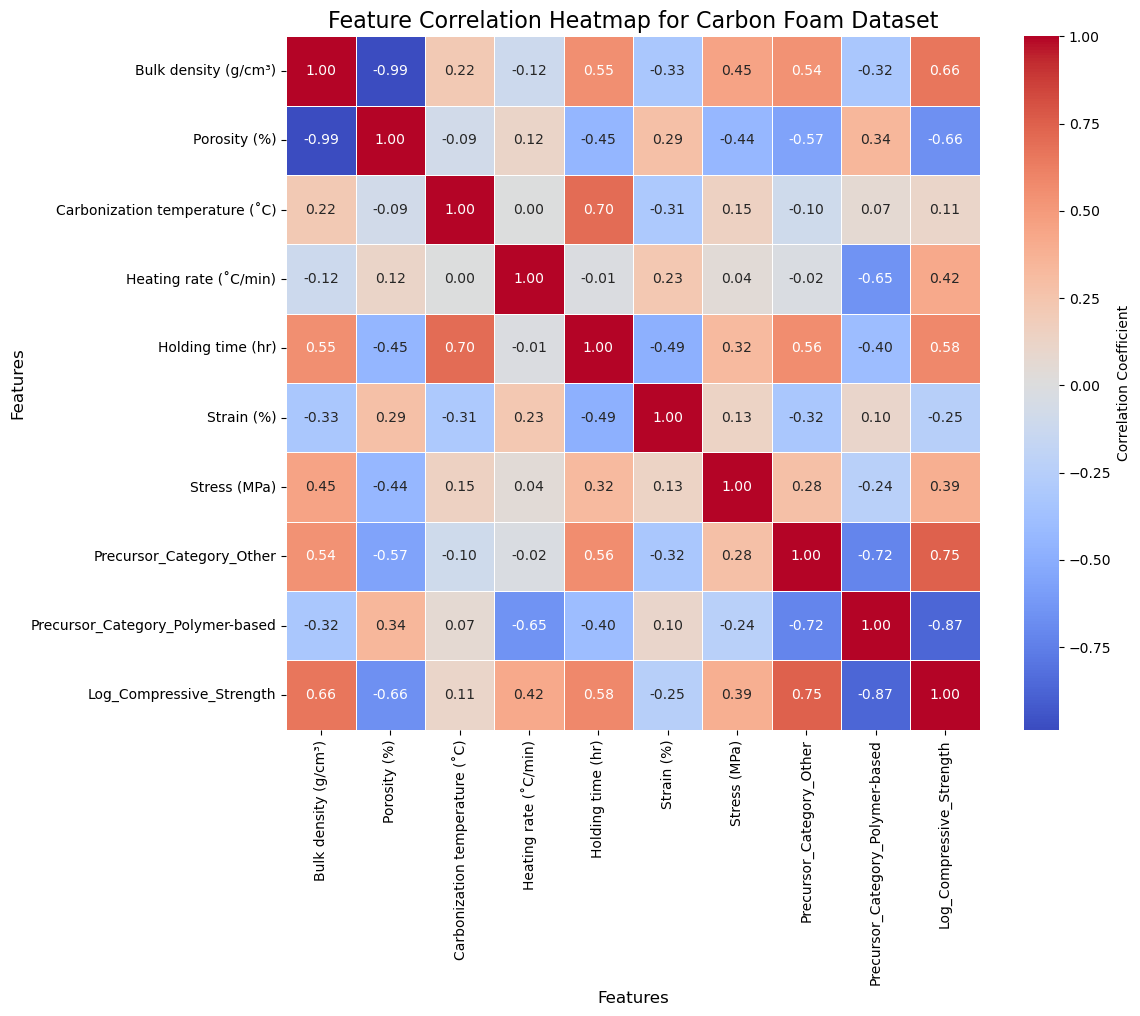

In [21]:
import os

temp_df = X.copy()
temp_df["Log_Compressive_Strength"] = y

# Create graphs folder if it does not exist
os.makedirs("graphs", exist_ok=True)

plt.figure(figsize=(12,10))

sns.heatmap(
    temp_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Correlation Coefficient"}
)

plt.title("Feature Correlation Heatmap for Carbon Foam Dataset", fontsize=16)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Features", fontsize=12)

plt.tight_layout()

# Save the graph
plt.savefig("graphs/correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

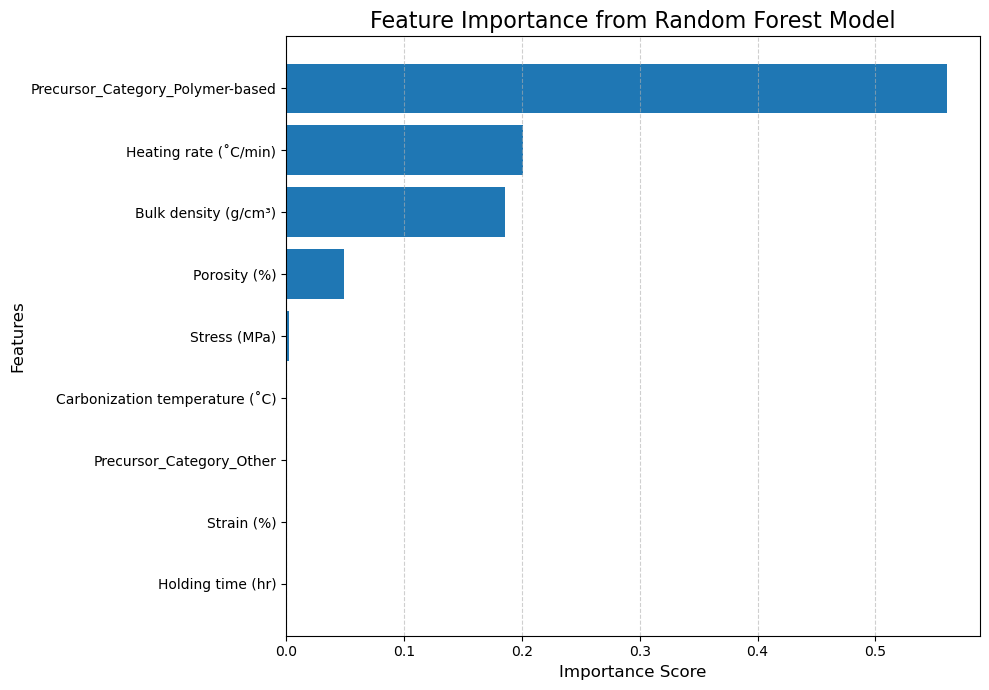

,Feature,Importance
8,Precursor_Category_Polymer-based,0.560716
3,Heating rate (˚C/min),0.201328
0,Bulk density (g/cm³),0.185288
1,Porosity (%),0.049439
6,Stress (MPa),0.002758
2,Carbonization temperature (˚C),0.000139
7,Precursor_Category_Other,0.000129
5,Strain (%),0.000123
4,Holding time (hr),0.000079


In [22]:
import os

importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

# Create graphs folder if it does not exist
os.makedirs("graphs", exist_ok=True)

plt.figure(figsize=(10,7))

plt.barh(feature_importance["Feature"], feature_importance["Importance"])

plt.gca().invert_yaxis()

plt.title("Feature Importance from Random Forest Model", fontsize=16)
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.6)

plt.tight_layout()

# Save graph
plt.savefig("graphs/feature_importance_rf.png", dpi=300, bbox_inches="tight")

plt.show()

feature_importance

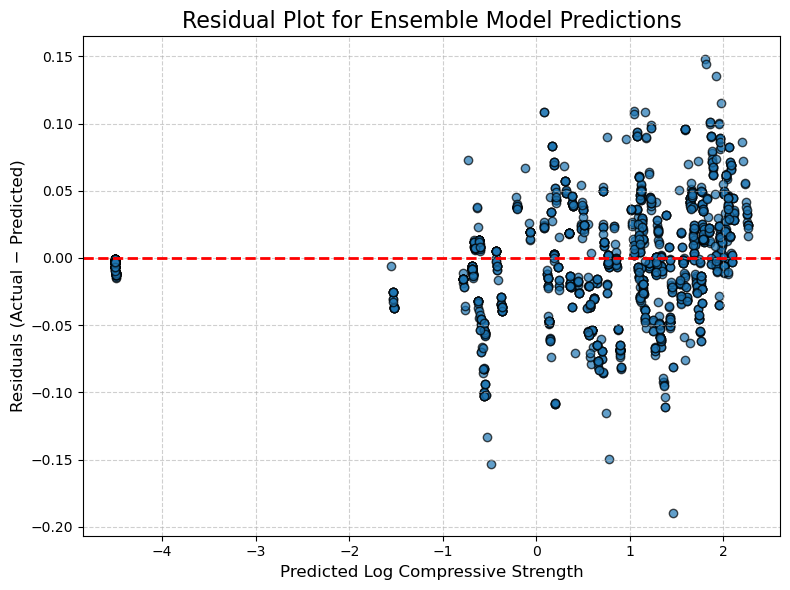

In [23]:
import os

residuals = y_test - ensemble_pred

# Create graphs folder if it does not exist
os.makedirs("graphs", exist_ok=True)

plt.figure(figsize=(8,6))

plt.scatter(
    ensemble_pred,
    residuals,
    edgecolors="black",
    alpha=0.7
)

plt.axhline(0, color="red", linestyle="--", linewidth=2)

plt.xlabel("Predicted Log Compressive Strength", fontsize=12)
plt.ylabel("Residuals (Actual − Predicted)", fontsize=12)

plt.title("Residual Plot for Ensemble Model Predictions", fontsize=16)

plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()

# Save graph
plt.savefig("graphs/residual_plot_ensemble.png", dpi=300, bbox_inches="tight")

plt.show()

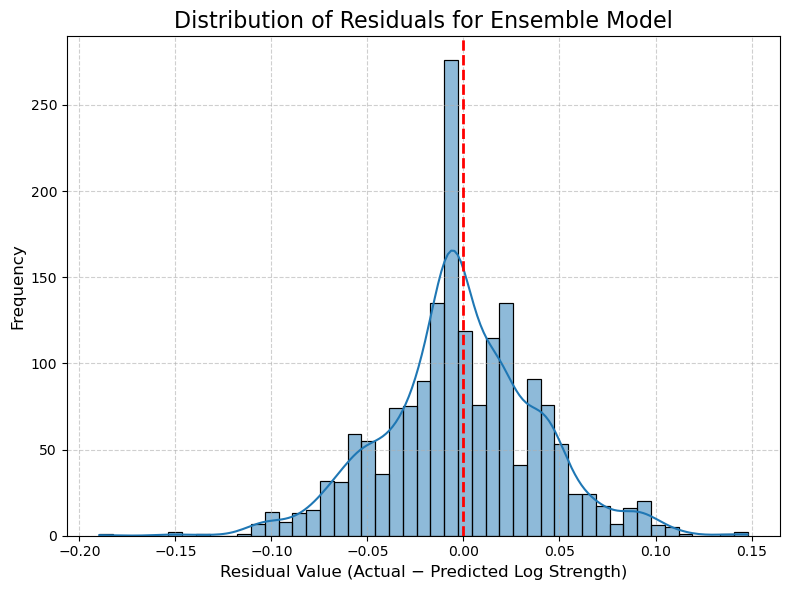

In [24]:
import os

# Create graphs folder if it does not exist
os.makedirs("graphs", exist_ok=True)

plt.figure(figsize=(8,6))

sns.histplot(residuals, kde=True)

plt.axvline(0, color="red", linestyle="--", linewidth=2)

plt.xlabel("Residual Value (Actual − Predicted Log Strength)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.title("Distribution of Residuals for Ensemble Model", fontsize=16)

plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()

# Save graph
plt.savefig("graphs/residual_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

In [33]:
def predict_strength(
    bulk_density,
    porosity,
    carbonization_temp,
    heating_rate,
    holding_time,
    precursor_category
):
    
    input_dict = {
        "Bulk density (g/cm³)": bulk_density,
        "Porosity (%)": porosity,
        "Carbonization temperature (˚C)": carbonization_temp,
        "Heating rate (˚C/min)": heating_rate,
        "Holding time (hr)": holding_time,
    }
    
    for col in X.columns:
        if "Precursor_Category_" in col:
            input_dict[col] = 0

    category_col = "Precursor_Category_" + precursor_category
    if category_col in input_dict:
        input_dict[category_col] = 1

    input_df = pd.DataFrame([input_dict])

# 🔥 FIX: Align columns with training data
    input_df = input_df.reindex(columns=X.columns, fill_value=0)

    rf_val = rf.predict(input_df)[0]
    xgb_val = xgb.predict(input_df)[0]
    ensemble_val = (w_rf * rf_val) + (w_xgb * xgb_val)

    strength_mpa = 10 ** ensemble_val
    strength_mpa = round(float(strength_mpa), 3)

    print("\n======================================")
    print(" Carbon Foam Strength Prediction")
    print("======================================")
    print(f"Predicted Compressive Strength: {strength_mpa} MPa")
    print("======================================\n")

    return strength_mpa

In [34]:
predict_strength(
    bulk_density=0.45,
    porosity=80,
    carbonization_temp=900,
    heating_rate=5,
    holding_time=2,
    precursor_category="Pitch-based"
)


 Carbon Foam Strength Prediction
Predicted Compressive Strength: 110.846 MPa



110.846

In [ ]:
import joblib

joblib.dump(rf, "rf_model.pkl")
joblib.dump(xgb, "xgb_model.pkl")

print("Models saved.")

In [ ]:
import tkinter as tk
from tkinter import ttk
import pandas as pd
import numpy as np

# ===============================
# Prediction Function
# ===============================

def predict_strength_gui():
    try:
        bulk_density = float(entry_bulk.get().strip())
        porosity = float(entry_poro.get().strip())
        carbon_temp = float(entry_temp.get().strip())
        heating_rate = float(entry_heat.get().strip())
        holding_time = float(entry_hold.get().strip())
        precursor = combo_precursor.get().strip()

        if precursor == "":
            result_var.set("Select precursor category")
            return

        # Prepare input dictionary
        input_dict = {
            "Bulk density (g/cm³)": bulk_density,
            "Porosity (%)": porosity,
            "Carbonization temperature (˚C)": carbon_temp,
            "Heating rate (˚C/min)": heating_rate,
            "Holding time (hr)": holding_time,
        }

        # Initialize all category columns to 0
        for col in X.columns:
            if "Precursor_Category_" in col:
                input_dict[col] = 0

        # Activate selected category
        category_col = "Precursor_Category_" + precursor
        if category_col in input_dict:
            input_dict[category_col] = 1

        input_df = pd.DataFrame([input_dict])

        # Predict
        rf_val = rf.predict(input_df)[0]
        xgb_val = xgb.predict(input_df)[0]
        ensemble_val = (w_rf * rf_val) + (w_xgb * xgb_val)

        strength_mpa = 10 ** ensemble_val
        strength_mpa = round(float(strength_mpa), 3)

        result_var.set(f"{strength_mpa} MPa")

    except Exception as e:
        result_var.set(str(e))


# ===============================
# GUI Layout
# ===============================

root = tk.Tk()
root.title("Carbon Foam Strength Predictor")
root.geometry("520x580")
root.configure(bg="#f4f6f8")

title = tk.Label(root,
                 text="Carbon Foam Compressive Strength Predictor",
                 font=("Helvetica", 16, "bold"),
                 bg="#f4f6f8",
                 fg="#1f2d3d")
title.pack(pady=20)

frame = tk.Frame(root, bg="#f4f6f8")
frame.pack(pady=10)

labels = [
    "Bulk Density (g/cm³)",
    "Porosity (%)",
    "Carbonization Temp (°C)",
    "Heating Rate (°C/min)",
    "Holding Time (hr)"
]

entries = []

for i, label_text in enumerate(labels):
    label = tk.Label(frame,
                     text=label_text,
                     font=("Helvetica", 11),
                     bg="#f4f6f8")
    label.grid(row=i, column=0, pady=10, padx=15, sticky="w")

    entry = ttk.Entry(frame, width=28)
    entry.grid(row=i, column=1, pady=10)
    entries.append(entry)

entry_bulk, entry_poro, entry_temp, entry_heat, entry_hold = entries

# Precursor dropdown
tk.Label(frame,
         text="Precursor Category",
         font=("Helvetica", 11),
         bg="#f4f6f8").grid(row=5, column=0, pady=12, padx=15, sticky="w")

combo_precursor = ttk.Combobox(
    frame,
    values=[
        "Composite-based",
        "Other",
        "Pitch-based",
        "Polymer-based",
        "Resin-based"
    ],
    width=25,
    state="readonly"
)
combo_precursor.grid(row=5, column=1, pady=12)

# Predict Button
predict_btn = tk.Button(root,
                        text="Predict Strength",
                        command=predict_strength_gui,
                        font=("Helvetica", 12, "bold"),
                        bg="#007acc",
                        fg="white",
                        width=22,
                        height=2)
predict_btn.pack(pady=25)

# Result Display
result_var = tk.StringVar()

result_box = tk.Label(root,
                      textvariable=result_var,
                      font=("Helvetica", 18, "bold"),
                      bg="#ffffff",
                      fg="#2e7d32",
                      width=22,
                      height=2,
                      relief="ridge")
result_box.pack(pady=20)

root.mainloop()

In [ ]:
streamlit run streamlit_app.py